In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
sc.settings.set_figure_params(dpi=100)
import warnings
warnings.filterwarnings('ignore')

### Helper Functions

In [2]:
# define a function to normalize a dataset
def normalize(gex):
    return (gex.T / np.sqrt((gex ** 2).sum(1))).T
# define a function to clip the data to a given range
def clip(gex, low, high):
    gex[gex < low] = low
    gex[gex > high] = high
    return gex
# define a function to compute RMSE
def rmse(old, new):
    return np.sqrt(np.mean((new - old) ** 2))
# define a function to add noise
def add_noise(gex, std):
    gex += np.random.normal(0, std, size=(n_cells, n_genes))
    return gex

### Generate Complex Directed Graphs

[Text(0.5, 0, 'Epochs'), Text(0, 0.5, 'RMSE from Previous')]

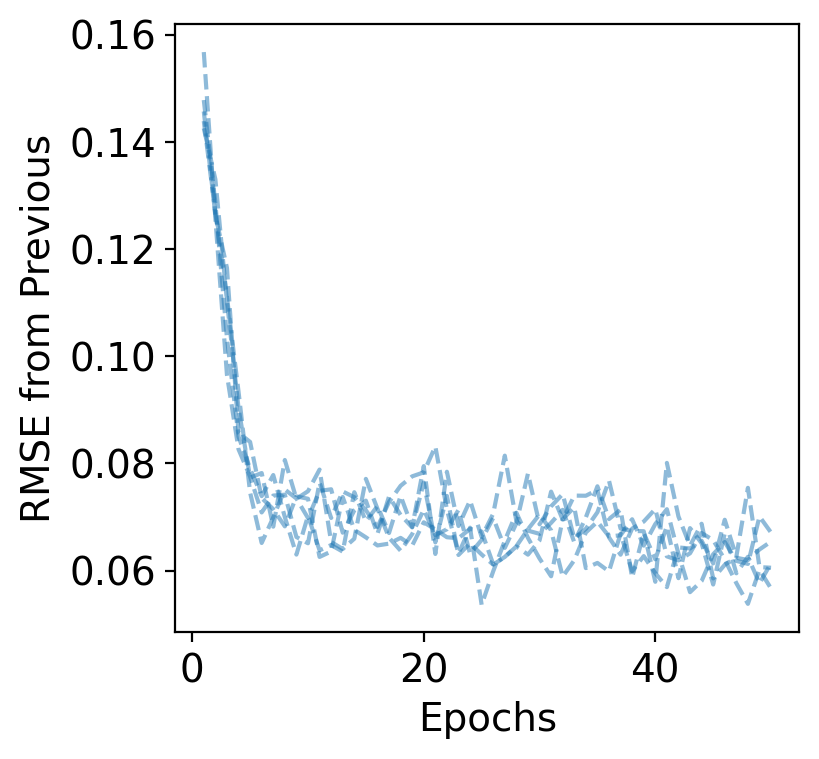

In [119]:
from anndata import AnnData
# define a potential graph
n_genes = 4
n_cells = 100
iters = 50
rounds = 5
learning_rate = 5e-1
nodes = np.arange(n_genes)
# randomly determine edges
np.random.seed(0)
edges, edges_true = [], []
for start in nodes[:-1]:
    for end in nodes[start+1:]:
        strength = np.random.choice([-1, 0, 1], size=1)
        edges.append([start, end, strength])
        edges_true.append((start, end, strength))
# loop through random seeds to generate data
adatas = []
# plot the RMSEs
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
for seed in range(rounds):
    # set random seed
    np.random.seed(seed)
    # generate a random dataset
    gex = np.random.uniform(0, 1, size=(n_cells, n_genes))
    gex = normalize(gex)
    # normalize the dataset according to the ruleset
    rmses = []
    for _ in range(iters):
        gex_new = gex.copy()
        # adjust the data according to edges
        order = np.random.choice(range(len(edges)), size=len(edges), replace=False)
        edges_ordered = [edges[idx] for idx in order]
        for node1, node2, weight in edges_ordered:
            gex_new[:, node2] += gex_new[:, node1] * weight * learning_rate
        gex_new = add_noise(gex_new, 0.1)
        gex_new = clip(gex_new, 0, 1)
        gex_new = normalize(gex_new)
        rmses.append(rmse(gex, gex_new))
        gex = gex_new
    # convert into anndata object
    adata = AnnData(gex)
    adatas.append(adata)
    # plot the RMSEs
    ax.plot(range(1, len(rmses)+1), rmses, color='tab:blue', linestyle='--', alpha=0.5)
ax.set(xlabel='Epochs', ylabel='RMSE from Previous')

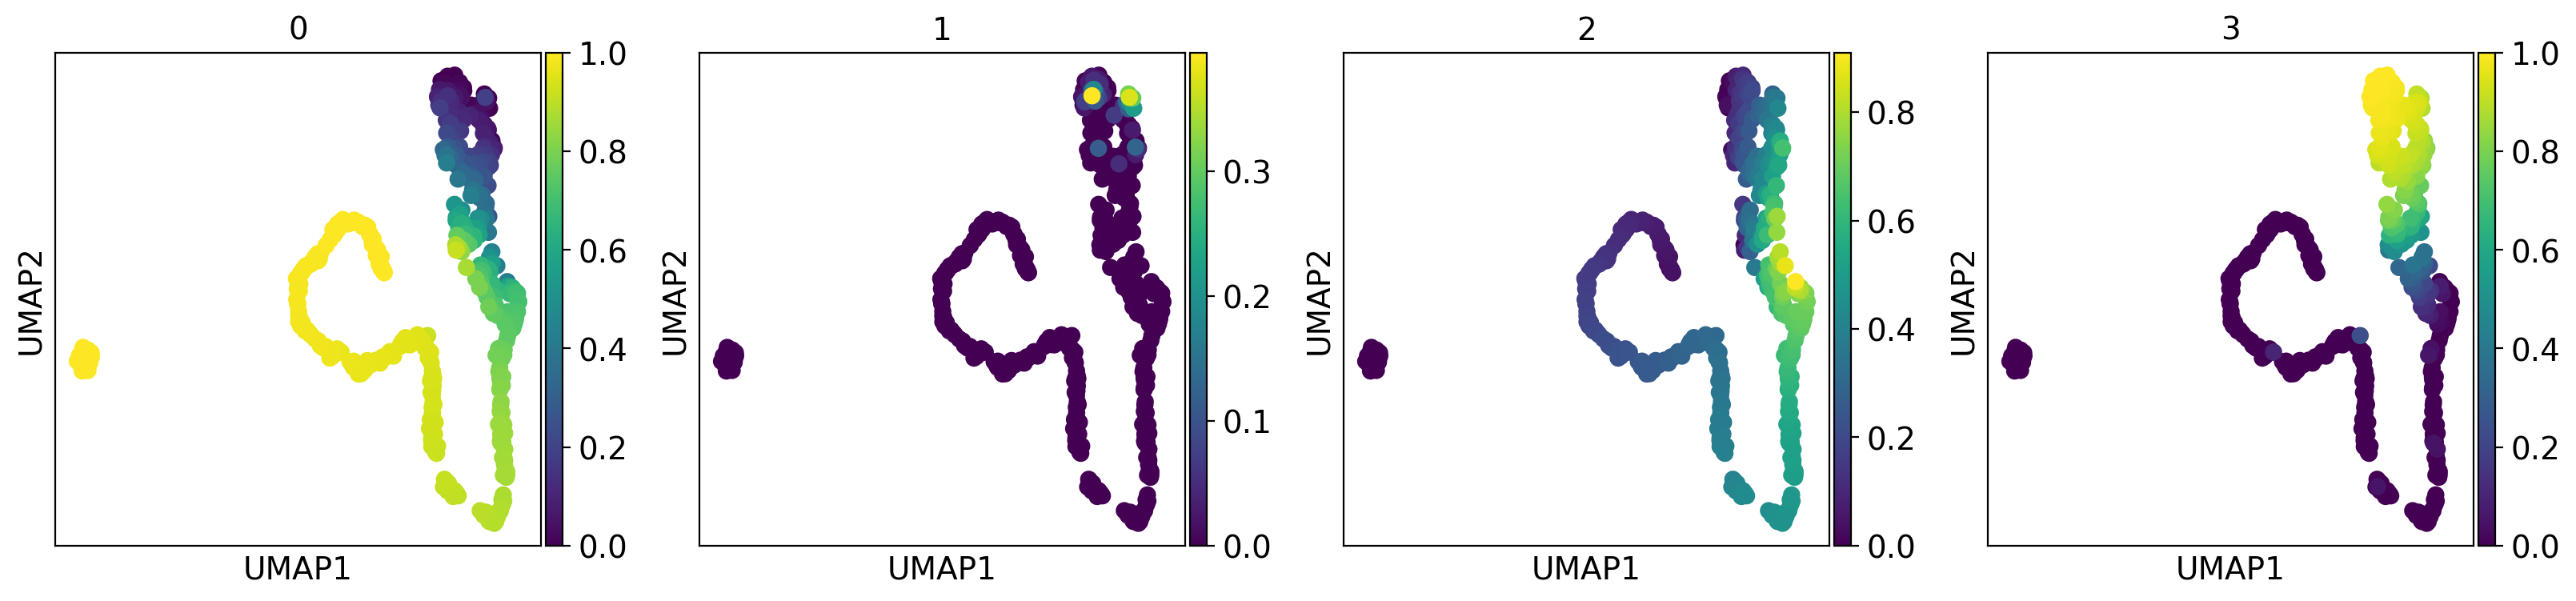

In [120]:
# aggregate the data together
adata = adatas[0].concatenate(adatas[1:])
sc.pp.neighbors(adata, use_rep='X', random_state=0)
sc.tl.umap(adata, random_state=0)
sc.pl.umap(adata, color=['0','1','2','3'], ncols=4)

In [121]:
# plot the graph of the network
import networkx as nx
import matplotlib as mpl
# set seed
seed = 0
# add nodes to graph
G = nx.DiGraph(nodes=nodes)
# add single edges to graph
for start, end, weight in edges:
    G.add_edge(start, end, weight=weight, strength=abs(weight))
# create a layout of the genes
pos = {0:[0, 0], 1:[0, 1], 2:[1, 0], 3:[1, 1]}

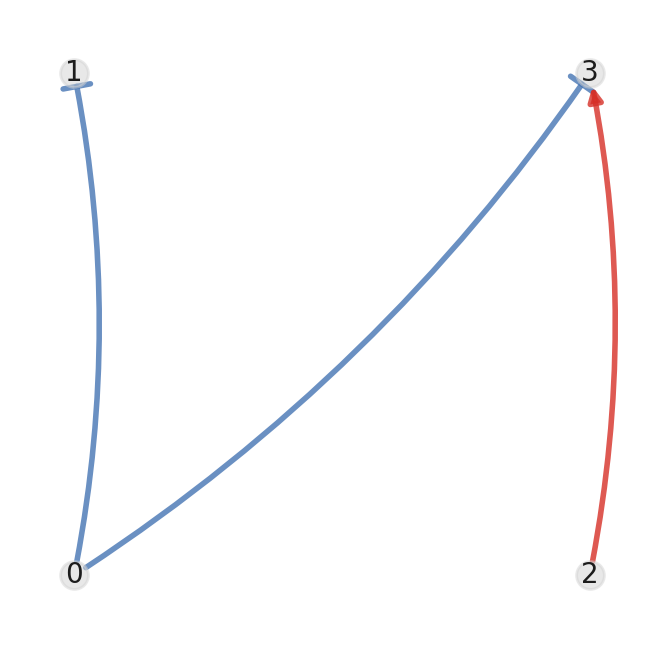

In [122]:
# determine parameters for graph plotting
node_size = 1e2
node_color = 'lightgray'
cmap = plt.cm.RdYlBu
edge_weights = [G.get_edge_data(*edge)['weight'] for edge in G.edges]
arrowstyle_inhib = mpl.patches.ArrowStyle('|-|, widthA=0.0, angleA=0, widthB=0.5, angleB=0')
arrowstyle_promo = mpl.patches.ArrowStyle('-|>')
edges_inhib = [x for x, weight in zip(G.edges(), edge_weights) if weight < 0]
edges_promo = [x for x, weight in zip(G.edges(), edge_weights) if weight > 0]
widths_inhib = [2 * abs(weight) for weight in edge_weights if weight < 0]
widths_promo = [2 * abs(weight) for weight in edge_weights if weight > 0]
arrowsize = 10
width = 4
# draw the graph using preset parameters
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color, alpha=0.5)
edges = nx.draw_networkx_edges(G, pos, node_size=node_size, arrowstyle=arrowstyle_inhib, alpha=0.8,
                               arrowsize=arrowsize, edge_color=mpl.colors.to_hex(cmap(0.9)), width=widths_inhib,
                               connectionstyle='arc3, rad=0.1', edgelist=edges_inhib)
edges = nx.draw_networkx_edges(G, pos, node_size=node_size, arrowstyle=arrowstyle_promo, alpha=0.8,
                               arrowsize=arrowsize, edge_color=mpl.colors.to_hex(cmap(0.1)), width=widths_promo,
                               connectionstyle='arc3, rad=0.1', edgelist=edges_promo)
# retrieve the current axis and turn off the axes
ax = plt.gca()
ax.set_axis_off()
# add on node labels
for label, coords in pos.items():
    ax.text(*coords, label, fontsize=10, color='#1c1c1c', va='center', ha='center')

## Test the performance of simple correlations

In [123]:
# retrieve correlation data
df_corr = pd.DataFrame(adata.X).corr()

In [124]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve
# load into the prediction frame
df_in = pd.DataFrame(columns=['pred','true'])
for i1, i2, s in edges_true:
    df_in.loc[df_in.shape[0]] = df_corr.iloc[i1, i2], s[0]
# test for the presence of connections
df_in = abs(df_in)
# collect statistics
fpr, tpr, _ = roc_curve(df_in['true'], df_in['pred'])
auroc = auc(fpr, tpr)
pre, rec, _ = precision_recall_curve(df_in['true'], df_in['pred'])
auprc = auc(rec, pre)
print(auroc, auprc)

0.6666666666666666 0.8166666666666667


## Test performance with Celcomen

In [125]:
import torch
import torch_geometric
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from sklearn.neighbors import kneighbors_graph
# define the number of neighbors (six for visium)
n_neighbors = 6
# define the celcomen class
class celcomen(torch.nn.Module):
    # define initialization function
    def __init__(self, input_dim, output_dim, n_neighbors, seed=0):
        super(celcomen, self).__init__()
        # define the seed
        torch.manual_seed(seed)
        # set up the graph convolution
        self.conv1 = GCNConv(input_dim, output_dim, add_self_loops=False)
        # set up the linear layer for intracellular gene regulation
        self.lin = torch.nn.Linear(input_dim, output_dim)
        # define the neighbors
        self.n_neighbors = n_neighbors
        # define a tracking variable for the gene expression x matrix
        self.gex = None

    # define a function to artificially set the g2g matrix
    def set_g2g(self, g2g):
        """
        Artifically sets the core g2g matrix to be a specified interaction matrix
        """
        # set the weight as the input
        self.conv1.lin.weight = torch.nn.Parameter(g2g, requires_grad=True)
        # and then set the bias as all zeros
        self.conv1.bias = torch.nn.Parameter(torch.from_numpy(np.zeros(len(g2g)).astype('float32')), requires_grad=False)

    # define a function to artificially set the g2g matrix
    def set_g2g_intra(self, g2g_intra):
        """
        Artifically sets the core g2g intracellular matrix to be a specified matrix
        """
        # set the weight as the input
        self.lin.weight = torch.nn.Parameter(g2g_intra, requires_grad=True)
        # and then set the bias as all zeros
        self.lin.bias = torch.nn.Parameter(torch.from_numpy(np.zeros(len(g2g_intra)).astype('float32')), requires_grad=False)

    # define a function to artificially set the sphex matrix
    def set_gex(self, gex):
        """
        Artifically sets the current sphex matrix
        """
        self.gex = torch.nn.Parameter(gex, requires_grad=False)
        
    # define the forward pass
    def forward(self, edge_index, batch):
        """
        Forward pass for prediction or training,
        convolutes the input by the expected interactions and returns log(Z_mft)
        """
        # compute the message
        msg = self.conv1(self.gex, edge_index)
        # compute intracellular message
        msg_intra = self.lin(self.gex)
        # compute the log z mft
        log_z_mft = self.log_Z_mft(edge_index, batch)
        return msg, msg_intra, log_z_mft

    # define approximation function
    def log_Z_mft(self, edge_index, batch):
        """
        Mean Field Theory approximation to the partition function. Assumptions used are:
        - expression of values of genes are close to their mean values over the visium slide
        - \sum_b g_{a,b} m^b >0 \forall a, where m is the mean gene expression and g is the gene-gene
          interaction matrix.
        """
        # retrieve number of spots
        num_spots = self.gex.shape[0]
        # calculate mean gene expression        
        mean_genes = torch.mean(self.gex, axis=0).reshape(-1,1)  # the mean should be per connected graph
        # calculate the norm of the sum of mean genes
        g = torch.norm(torch.mm( self.n_neighbors*self.conv1.lin.weight + 2*self.lin.weight, mean_genes))   # maybe needs to change to g = torch.norm(torch.mm(mean_genes, self.conv1.lin.weight))
        # calculate the contribution for mean values        
        z_mean = - num_spots  * torch.mm(torch.mm(torch.t(mean_genes), self.lin.weight + 0.5 * self.n_neighbors * self.conv1.lin.weight),  mean_genes)
        # calculate the contribution gene interactions
        z_interaction = self.z_interaction(num_spots=num_spots, g=g)
        # add the two contributions        
        log_z_mft = z_mean + z_interaction
        return log_z_mft

    def z_interaction(self, num_spots, g):
        """
        Avoid exploding exponentials by returning an approximate interaction term for the partition function.
        """
        if g>20:
            z_interaction = num_spots * ( g - torch.log( g) )
        else:
            z_interaction = num_spots * torch.log((torch.exp( g) - torch.exp(- g))/( g))
        return z_interaction

In [144]:
# define a function to normalize the g2g
def normalize_g2g(g2g):
    """
    Addresses any small fluctuations in symmetrical weights
    """
    # symmetrize the values
    g2g = (g2g + g2g.T) / 2
    # force them to be between 0-1
    g2g[g2g < 0] = 0
    g2g[g2g > 1] = 1
    # force the central line to be 1
    for idx in range(len(g2g)):
        g2g[idx, idx] = 1
    return g2g

In [145]:
# create 10, 10 grids
ys = np.repeat(np.arange(10).reshape(-1, 1), 10, axis=1)
xs = np.repeat(np.arange(10).reshape(-1, 1), 10, axis=1).T
ys = ys.flatten().tolist() * rounds
xs = xs.flatten().tolist() * rounds
adata.obsm['spatial'] = np.array([xs, ys]).T

In [146]:
# create a tracking variable of the datas for the dataloader
data_list = []
# loop through each sample
for batch in adata.obs['batch'].unique():
    # define the mask
    mask = adata.obs['batch'] == batch
    # retrieve positions from the data
    pos = torch.from_numpy(adata[mask].obsm['spatial'].astype('float32'))
    # convert the gene expression data to numpy
    x = torch.from_numpy(adata[mask, :].X.astype('float32'))
    # sphere normalize the data (just in case)
    norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
    assert (norm_factor > 0).all()
    x = torch.div(x, norm_factor)
    y = torch.Tensor([0])  # here we will store GT value
    # find the edges via kneighbors, not including self because we are considering intercellular
    edge_index = kneighbors_graph(pos, n_neighbors, include_self=False).todense()
    edge_index = torch.from_numpy(np.array(np.where(edge_index)))
    # create the final torch geometric graph dataframe
    data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
    data.validate(raise_on_error=True)  # performs basic checks on the graph
    # store the data in the data list tracker
    data_list.append(data)
# convert into a data loader
data_loader = DataLoader(data_list, batch_size=1, shuffle=True)

In [147]:
from tqdm import tqdm
# define the parameters of the model
learning_rate = 5e-2
learning_rate_all = 5e-2
zmft_scalar = 1e-1
seed = 0
epochs = 50

In [148]:
# instantiate the model, input and output will be the same
def train_celcomen(data_loader):
    model_rev = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # now perform the simulation
    np.random.seed(seed)
    # artifically set the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes), low=-1, high=1).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model_rev.set_g2g(torch.from_numpy(input_g2g))
    model_rev.set_g2g_intra(torch.from_numpy(input_g2g))

    # setup the initial optimizer
    optimizer = torch.optim.SGD(model_rev.parameters(), lr=learning_rate, momentum=0)
    # keep track of the losses
    loss, losses = None, []
    model_rev.train()
    # retrieve the two matrices
    epoch = -1
    # work through epochs
    for epoch in tqdm(range(epochs), total=epochs):
        # loop thorugh each data object
        losses_ = []
        for idx, data in enumerate(data_loader):
            # set the appropriate gex
            model_rev.set_gex(data.x)
            # derive the message as well as the mean field approximation
            msg, msg_intra, log_z_mft = model_rev(data.edge_index, 1)
            # compute the loss and track it
            loss = -(-log_z_mft + zmft_scalar * torch.trace(torch.mm(msg, torch.t(model_rev.gex))) + zmft_scalar * torch.trace(torch.mm(msg_intra, torch.t(model_rev.gex))) )
            losses_.append(loss.detach().numpy()[0][0])
            # derive the gradients, update, and clear
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            # repeatedly force a normalization
            model_rev.conv1.lin.weight = torch.nn.Parameter(normalize_g2g(model_rev.conv1.lin.weight), requires_grad=True)
            model_rev.lin.weight = torch.nn.Parameter(normalize_g2g(model_rev.lin.weight), requires_grad=True)
            optimizer = torch.optim.SGD(model_rev.parameters(), lr=learning_rate, momentum=0)
    return model_rev

100%|███████████████████████████████████████████| 50/50 [00:00<00:00, 86.17it/s]


In [149]:
# retrieve the two frames
df_g2g_extra = pd.DataFrame(model_rev.conv1.lin.weight.detach().cpu().numpy())
df_g2g_intra = pd.DataFrame(model_rev.lin.weight.detach().cpu().numpy())
# load into the prediction frame
df_in = pd.DataFrame(columns=['pred','true'])
for i1, i2, s in edges_true:
    df_in.loc[df_in.shape[0]] = df_g2g_intra.iloc[i1, i2], s[0]
# test for the presence of connections
df_in = abs(df_in)
# collect statistics
fpr, tpr, _ = roc_curve(df_in['true'], df_in['pred'])
auroc_intra = auc(fpr, tpr)
pre, rec, _ = precision_recall_curve(df_in['true'], df_in['pred'])
auprc_intra = auc(rec, pre)
# load into the prediction frame
df_in = pd.DataFrame(columns=['pred','true'])
for i1, i2, s in edges_true:
    df_in.loc[df_in.shape[0]] = df_g2g_extra.iloc[i1, i2], s[0]
# test for the presence of connections
df_in = abs(df_in)
# collect statistics
fpr, tpr, _ = roc_curve(df_in['true'], df_in['pred'])
auroc_extra = auc(fpr, tpr)
pre, rec, _ = precision_recall_curve(df_in['true'], df_in['pred'])
auprc_extra = auc(rec, pre)
return auroc_pcorr, auroc_scorr, auroc_intra, auroc_extra, auprc_pcorr, auprc_scorr, auprc_intra, auprc_extra

<!-- Truth:
[-1, 0, 1] T0
--> [ 1, 0, 1] T1
--> [ 0, 0, 1] T2
--> [-1, 0, 0] T3
Celcomen:
[0, 0.5, 1] C0
--> [-1, 0, 1] --> [1, 0, 1] C1

<!--
# For [N_Genes = 4, 10, 25, 100]
    # > For [Extra, Intra]:
        # >> Corr(T0, C0)
        # >> AUC(T1, C0)
        # >> AUC(T2, C0)
        # >> AUC(T3, -C0)
--> -->

0.5 0.75


0.5 0.75
